# 01 - Data Construction, Clustering & Time Series


## Outputs
- `tmp/policy_cited_paper.pickle` - Main dataset (papers cited by policy documents)
- `tmp/abstract_embedding.pickle` - Abstract embeddings (OpenAI text-embedding-3-large)
- `tmp/partition_info.pickle` - Cluster information (TF-IDF keywords, names, growth rates)
- `tmp/year_cited.pickle` - Cumulative policy citation status by year
- `tmp/year_cited_raw.pickle` - Raw annual policy citation data
- `output/figures/figS2_policy_citation_growth.eps` - Policy citation growth rate figure

In [1]:
# === Setup ===
import sys
sys.path.append('..')

from config.settings import (
    TmpPaths, OutputPaths, DATA_DIR,
    SCOPUS_BASE, POLICY_CITE_BASE,
    YEAR_RANGE, PARTITION_COLORS, PARTITION_NAMES
)
from src.utils import flatten
from src.data_loader import load_pickle, save_pickle
from src.plotting import setup_plot_style, save_figure

In [ ]:
import datetime
import itertools
import time
import collections
import glob
import ast
import os

import pandas as pd
import numpy as np
import networkx as nx
import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Stopwords
stopwords_list = list(set(stopwords.words('english')) | set(['abstract', 'paper', 'elsevier', '00']))

---
## 1. Load DOI List & Merge Scopus Data

In [9]:
datas = pd.concat([pd.read_csv(f, on_bad_lines='skip') 
                   for f in glob.glob(str(DATA_DIR / 'doi_list' / '*.csv'))])
print(f"DOI list: {len(datas)} rows, {datas.DOI.nunique()} unique DOIs")

DOI list: 305788 rows, 305635 unique DOIs


In [22]:
doi = load_pickle(SCOPUS_BASE / 'paper' / 'doi.pickle')
doi_pc = set(datas.DOI)
doi_pc = doi[doi.isin(doi_pc)]
eid_pc = list(set(doi_pc.index))
print(f"Matched EIDs: {len(eid_pc)}")

Matched EIDs: 239754


In [ ]:

def load_pickle_eid(f,eid_pc):
    r = load_pickle(f)
    r = r.loc[list(set(r.index)&set(eid_pc))]
    print(f,len(eid_pc),len(r))
    return r
    
policy_cited_scopus = pd.concat(
    [load_pickle_eid(f,eid_pc) for f in glob.glob(str(SCOPUS_BASE / 'paper' / '*.pickle'))],
    axis=1)

policy_cited_scopus['citedby'] = load_pickle(SCOPUS_BASE / 'citation' / 'citedby.pickle')
policy_cited_scopus['reference'] = load_pickle(SCOPUS_BASE / 'citation' / 'reference.pickle')

policy_cited_scopus['Policy citation count'] = policy_cited_scopus.doi.map(
    datas.drop_duplicates(subset=['DOI']).set_index('DOI')['Policy citation count']
)
print(f"Policy cited papers (raw): {len(policy_cited_scopus)}")

---
## 2. Deduplication & Filtering

In [ ]:
policy_cited_scopus['tmp'] = 0
policy_cited_scopus['tmp'] = policy_cited_scopus['tmp'] \
    + policy_cited_scopus.doctype.apply(lambda x: 1 if x == 'Article' else 0) \
    + policy_cited_scopus.doctype.apply(lambda x: -0.1 if x == 'Note' else 0) \
    + policy_cited_scopus.doctype.apply(lambda x: -0.1 if x == 'Erratum' or x == 'Editorial' else 0) \
    + policy_cited_scopus.abstract.apply(lambda x: -0.5 if x == 'NO ABSTRACT' else 0)

policy_cited_scopus = policy_cited_scopus.sort_values(['doi', 'tmp'], ascending=[True, False])
print(f"Before dedup: {len(policy_cited_scopus)}")
policy_cited_scopus = policy_cited_scopus.drop_duplicates(subset=['doi'])
print(f"After dedup: {len(policy_cited_scopus)}")

In [ ]:
valid_doctypes = ['Article', 'Report', 'Conference paper', 'Letter']
policy_cited_scopus = policy_cited_scopus[policy_cited_scopus.doctype.isin(valid_doctypes)]

year_min, year_max = YEAR_RANGE
policy_cited_scopus = policy_cited_scopus.query(f'year <= {year_max} and year >= {year_min}')
print(f"After filters: {len(policy_cited_scopus)}")

In [ ]:
save_pickle(policy_cited_scopus, TmpPaths.POLICY_CITED_PAPER)

---
## 3. Abstract Embedding (OpenAI API)

**Note**: API calls are time-consuming and costly. Skip if embeddings already exist.

In [ ]:
def get_embeddings(df, model="text-embedding-3-large", dimensions=None):
    from openai import OpenAI
    client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
    
    print(f"Processing {len(df)} texts")
    try:
        df_ = df.dropna()
        df_ = df_[df_.apply(len) > 0]
        texts = [" ".join(text.replace("\n", " ").split(" ")[:300]) for text in df_]
        
        if dimensions:
            res = client.embeddings.create(input=texts, model=model, dimensions=dimensions)
        else:
            res = client.embeddings.create(input=texts, model=model)
        
        emb = [x.embedding for x in res.data]
        result = pd.DataFrame(np.stack(emb))
        result.index = df_.index
        return result
    except Exception as e:
        print(f"Error: {e}")
        time.sleep(30)
        return pd.DataFrame()


def do_embedding(df, batch_size=700):
    res = [get_embeddings(df.iloc[i:i+batch_size]) for i in range(0, len(df), batch_size)]
    return pd.concat(res)

In [ ]:
if TmpPaths.ABSTRACT_EMBEDDING.exists():
    print("Loading existing embeddings...")
    embeddings = load_pickle(TmpPaths.ABSTRACT_EMBEDDING)
else:
    print("Generating new embeddings...")
    embeddings = do_embedding(policy_cited_scopus.abstract.dropna())
    save_pickle(embeddings, TmpPaths.ABSTRACT_EMBEDDING)

print(f"Embeddings shape: {embeddings.shape}")

---
## 4. UMAP Dimensionality Reduction

In [ ]:
from cuml.manifold.umap import UMAP
reducer_2d = UMAP(n_components=2, n_neighbors=15, min_dist=0.2, init='spectral')
UMAP_2d = reducer_2d.fit_transform(embeddings.values)
UMAP_2d = pd.DataFrame(UMAP_2d, index=embeddings.index)
print(f"UMAP 2D shape: {UMAP_2d.shape}")

In [ ]:
reducer_12d = UMAP(n_components=12, n_neighbors=15, min_dist=0.2, init='spectral')
UMAP_12d = reducer_12d.fit_transform(embeddings.values)
UMAP_12d = pd.DataFrame(UMAP_12d, index=embeddings.index)
print(f"UMAP 12D shape: {UMAP_12d.shape}")

---
## 5. Co-citation Network & Leiden Clustering

In [ ]:
def do_leidenpartitioning(g, seed=10):
    part = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition, seed=seed)
    partition = pd.DataFrame({
        "node": [v['name'] for v in g.vs],
        "partition": part.membership
    }).set_index('node').partition
    return pd.Series(partition.to_dict()), part

In [ ]:
edges = pd.DataFrame([
    (k, i) 
    for k, v in policy_cited_scopus.citedby.dropna().items() 
    for i in v
])
edges = edges[edges[0].isin(policy_cited_scopus.index)]
edges = edges[edges[1].isin(policy_cited_scopus.index)]
print(f"Edges: {len(edges)}")

In [ ]:
G = ig.Graph.TupleList(edges.itertuples(index=False), directed=False)
print(f"Graph: {G.vcount()} nodes, {G.ecount()} edges")

In [ ]:
partitions, part = do_leidenpartitioning(G, seed=5255)
print(f"Top 20 partitions cover: {partitions.value_counts()[:20].sum()} papers")
print(partitions.value_counts()[:25])

In [ ]:
policy_cited_scopus['partition'] = partitions.apply(lambda x: -1 if x > 22 else x)
print(policy_cited_scopus.partition.value_counts())

---
## 6. TF-IDF & Cluster Naming

In [ ]:
def get_tfidf(df_sample_):
    df_sample = df_sample_.copy()
    df_sample.index = list(range(len(df_sample)))
    
    vectorizer = TfidfVectorizer(stop_words=stopwords_list)
    tfidf_matrix = vectorizer.fit_transform(df_sample.abstract)
    feature_names = vectorizer.get_feature_names_out()
    
    top_tfidf = {}
    for k, v in df_sample.groupby("partition"):
        aggregate_scores = np.asarray(tfidf_matrix[v.index].sum(axis=0)).ravel()
        term_scores = {feature_names[i]: aggregate_scores[i] for i in range(len(feature_names))}
        top_terms = list(pd.Series(term_scores).sort_values(ascending=False)[:100].index)
        top_tfidf[k] = top_terms
    
    return pd.Series(top_tfidf)

In [ ]:
tfidf_df = get_tfidf(policy_cited_scopus.sample(frac=0.5))
tfidf_df.index = [int(i) for i in tfidf_df.index]

In [ ]:
partition_names = PARTITION_NAMES

# partition_info
partition_info = pd.DataFrame({
    'top_tfidf': tfidf_df,
    'partition_name_GPT4': pd.Series(partition_names),
    'num_paper': policy_cited_scopus['partition'].value_counts()
})
partition_info

---
## 7. Integrate Annual Citation Data

In [5]:
folders = sorted(glob.glob(str(POLICY_CITE_BASE / 'yearly_policy_cite' / 'cited*')))
print(f"Found {len(folders)} yearly folders")

res = []
for folder in folders:
    print(folder.split("/")[-1])
    files = glob.glob(folder + '/*.csv')
    data = pd.concat([pd.read_csv(f, on_bad_lines='skip') for f in files])
    paper_dois = pd.Series(list(set(data.DOI)))
    paper_dois.index = list(set(data.DOI))
    paper_dois.name = folder
    paper_dois = paper_dois.apply(lambda x: 1)
    res.append(paper_dois)

year_cited_raw = pd.concat(res, axis=1)
year_cited_raw.columns = list(range(2015, 2015 + len(folders)))
year_cited_raw = year_cited_raw.fillna(0)
print(f"Year cited raw shape: {year_cited_raw.shape}")

Found 10 yearly folders
cited_in_2015
cited_in_2016
cited_in_2017
cited_in_2018
cited_in_2019
cited_in_2020
cited_in_2021
cited_in_2022
cited_in_2023
cited_in_2024
Year cited raw shape: (303698, 10)


In [6]:
save_pickle(year_cited_raw, TmpPaths.YEAR_CITED_RAW)

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/year_cited_raw.pickle


In [12]:
policy_cited_scopus = pd.read_pickle(TmpPaths.POLICY_CITED_PAPER)

partition_info= pd.read_pickle(TmpPaths.PARTITION_INFO)

In [13]:
year_cited = year_cited_raw.T.cumsum().T
for c in year_cited.columns:
    year_cited[c] = year_cited[c].apply(lambda x: 1 if x > 0 else 0)

year_cited = year_cited.loc[list(set(policy_cited_scopus.doi) & set(year_cited.index))]
print(f"Year cited shape: {year_cited.shape}")


save_pickle(year_cited, TmpPaths.YEAR_CITED)

Year cited shape: (230022, 10)
Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../tmp/year_cited.pickle


---
## 8. Growth Rate Calculation & Figure Generation

In [14]:
for y in range(2016, 2025):
    if y in year_cited_raw.columns:
        policy_cited_scopus[f'year_cited_{y}'] = policy_cited_scopus.doi.map(year_cited_raw[y])

In [15]:
tmp = pd.concat([
    policy_cited_scopus.query('partition >= 0').groupby(['partition'])[f'year_cited_{year}'].sum() 
    for year in range(2016, 2024)
], axis=1)

b_2020 = tmp['year_cited_2016'] + tmp['year_cited_2017'] + tmp['year_cited_2018'] + tmp['year_cited_2019']
a_2020 = tmp['year_cited_2020'] + tmp['year_cited_2021'] + tmp['year_cited_2022'] + tmp['year_cited_2023']

df = pd.concat([b_2020 / b_2020.sum(), a_2020 / a_2020.sum()], axis=1)
partition_info['growth'] = (df[1] / df[0]).sort_values()

print(partition_info[['partition_name_GPT4', 'num_paper', 'growth']])

              partition_name_GPT4  num_paper    growth
-1.0                          NaN       8223       NaN
 0.0          Economy and Finance      21218  0.888511
 1.0   Environmental Conservation      16358  0.916693
 2.0                   Healthcare      14741  0.991835
 3.0                Energy Policy      13250  1.068435
 4.0             Education System      12696  0.994994
 5.0          Marine Conservation      12621  0.870628
 6.0             Climate Modeling      12485  1.135445
 7.0               Social Welfare      12484  0.942205
 8.0             Covid19 Pandemic      12190  5.163312
 9.0               Urban Planning      10526  1.001797
 10.0         Infectious Diseases       7371  0.800249
 11.0       Antibiotic Resistance       5644  1.057401
 12.0               Public Health       5543  1.061990
 13.0              Urban Mobility       5096  1.088582
 14.0           Plastic Pollution       5075  0.951175
 15.0              Drug Forensics       4841  0.249139
 16.0     

In [16]:
partition_info['color'] = pd.Series({i: c for i, c in enumerate(PARTITION_COLORS)})

In [17]:
# Figure S2: Policy Citation Growth
import scienceplots
from adjustText import adjust_text
import matplotlib.patches as mpatches
from matplotlib.path import Path

plt.style.use(['science'])
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "axes.spines.right": False,
    "axes.spines.top": False,
})
plt.rcParams['text.latex.preamble'] = r'\usepackage{arial}\renewcommand{\familydefault}{\sfdefault}'

def label_point(x, y, val, ax, size=9):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    return [ax.text(point['x'] + .02, point['y'], str(point['val']).replace("&", "and"), size=size) 
            for i, point in a.iterrows()]

Saved: /disks/qnap4/users/t-asatani/code_final/notebooks/../output/figures/figS2_policy_citation_growth.pdf


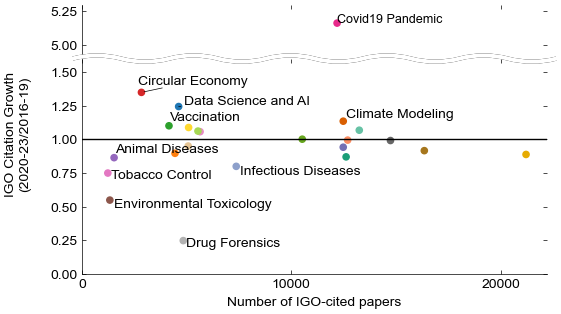

In [19]:
partition_info_ = partition_info.dropna(subset=['partition_name_GPT4'])

fig, ax = plt.subplots(nrows=2, figsize=(6, 3.5), sharex='col',
                       gridspec_kw={'height_ratios': (0.4, 1.6)})
fig.patch.set_facecolor('white')

partition_info_.plot.scatter(x='num_paper', y='growth', c='color', ax=ax[0])
partition_info_.plot.scatter(x='num_paper', y='growth', c='color', ax=ax[1])

fig.subplots_adjust(hspace=0.0)

ax[1].set_ylim(0, 1.6)
ax[0].set_ylim(4.9, 5.3)

ax[1].spines['top'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

ax[0].set_yticks([5, 5.25])
ax[1].set_yticks([0, 0.25, 0.5, 0.75, 1, 1.25, 1.5])

partition_info_2 = partition_info_.query('growth > 5')
texts = label_point(partition_info_2.num_paper, partition_info_2.growth,
                    partition_info_2.partition_name_GPT4, ax[0])

d1 = 0.02
d2 = 0.03
wn = 21
pp = (0, d2, 0, -d2)
px = np.linspace(-d1, 1 + d1, wn)
py = np.array([1 + pp[i % 4] for i in range(0, wn)])
p = Path(list(zip(px, py)), [Path.MOVETO] + [Path.CURVE3] * (wn - 1))

line1 = mpatches.PathPatch(p, lw=3, edgecolor='black', facecolor='None', 
                           clip_on=False, transform=ax[1].transAxes, zorder=10)
line2 = mpatches.PathPatch(p, lw=3, edgecolor='white', facecolor='None', 
                           clip_on=False, transform=ax[1].transAxes, zorder=10, capstyle='round')
ax[1].add_patch(line1)
ax[1].add_patch(line2)

ax[0].minorticks_off()
ax[1].minorticks_off()
ax[0].set_ylabel('')
ax[1].set_ylabel('IGO Citation Growth\n(2020-23/2016-19)')
ax[1].yaxis.set_label_coords(-0.11, 0.65)
ax[1].set_xlabel(r'Number of IGO-cited papers')
ax[1].set_xticks([0, 10000, 20000])

partition_info_1 = partition_info_.query('growth < 5 and growth > 1.1 or growth < 0.87')
texts = label_point(partition_info_1.num_paper, partition_info_1.growth,
                    partition_info_1.partition_name_GPT4, ax[1], size=10)
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5, zorder=3))

plt.axhline(1, c='black')

output_path = OutputPaths.FIGURES / 'figS2_policy_citation_growth.eps'
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path)
output_path = OutputPaths.FIGURES / 'figS2_policy_citation_growth.pdf'
fig.savefig(output_path)
print(f"Saved: {output_path}")

---
## 9. Final Save

In [ ]:
# policy_cited_scopus 
save_pickle(policy_cited_scopus, TmpPaths.POLICY_CITED_PAPER)
print(f"Saved: {TmpPaths.POLICY_CITED_PAPER}")

In [ ]:
# partition_info
save_pickle(partition_info[['top_tfidf', 'partition_name_GPT4', 'num_paper', 'growth', 'color']], 
            TmpPaths.PARTITION_INFO)
print(f"Saved: {TmpPaths.PARTITION_INFO}")

---
## Output Summary

| File | Description |
|------|-------------|
| `tmp/policy_cited_paper.pickle` | Main dataset (paper metadata + partition assignment) |
| `tmp/abstract_embedding.pickle` | Abstract embedding vectors |
| `tmp/partition_info.pickle` | Cluster info (TF-IDF, names, paper counts, growth rates) |
| `tmp/year_cited.pickle` | Cumulative citation status |
| `tmp/year_cited_raw.pickle` | Raw annual citation data |
| `output/figures/figS2_policy_citation_growth.eps` | Policy Citation Growth Figure |